[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ReevesJustin/data-driven-reloading/blob/main/notebooks/07_Real_Examples_-_Dissecting_Common_Myths.ipynb)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/ReevesJustin/data-driven-reloading/main?filepath=notebooks/07_Real_Examples_-_Dissecting_Common_Myths.ipynb)

Time to complete: 10-15 minutes

# Real Examples - Dissecting Common Myths

## Goal: Apply lessons to popular methods

OCW: Show how small samples make multiple charge weights look "forgiving."
**Velocity nodes/flat spots:** Simulate charge ladders: random data creates apparent flats.
**Barrel tuners:** Simulate dispersion: random tight groups appear with any setting.
**Atterlee 10-shot method:** Explain why 10 shots aren't enough to detect real differences reliably.
**Seating depth sweet spots:** Show how random variation creates fake optimal depths in seating depth tests.
**Brass sorting by weight:** Demonstrate that sorting by weight doesn't consistently improve precision beyond measurement error.
Each with **interactive sims** so learners see the illusion themselves.

## Tuner Test

A simple test for a "tuner" is to shoot a minimum of 10 rounds per setting (average or mean radius).

In [1]:
# Simulate tuner settings
settings = ['Low', 'Mid', 'High']
groups = {s: np.random.normal(0, 0.5, (10, 2)) for s in settings}

plt.figure(figsize=(8, 6))
for s, group in groups.items():
    plt.scatter(group[:,0], group[:,1], label=s)
plt.legend()
plt.title('Tuner Settings - Random Variation')
plt.show()

NameError: name 'np' is not defined

## 10 Shot Load Development

### Theory
The method of testing 10 shots per load over a range involves shooting 10 rounds for each powder charge increment to find the "sweet spot" where velocity is consistent or group size is small. This is often used in load development to identify optimal charges quickly.

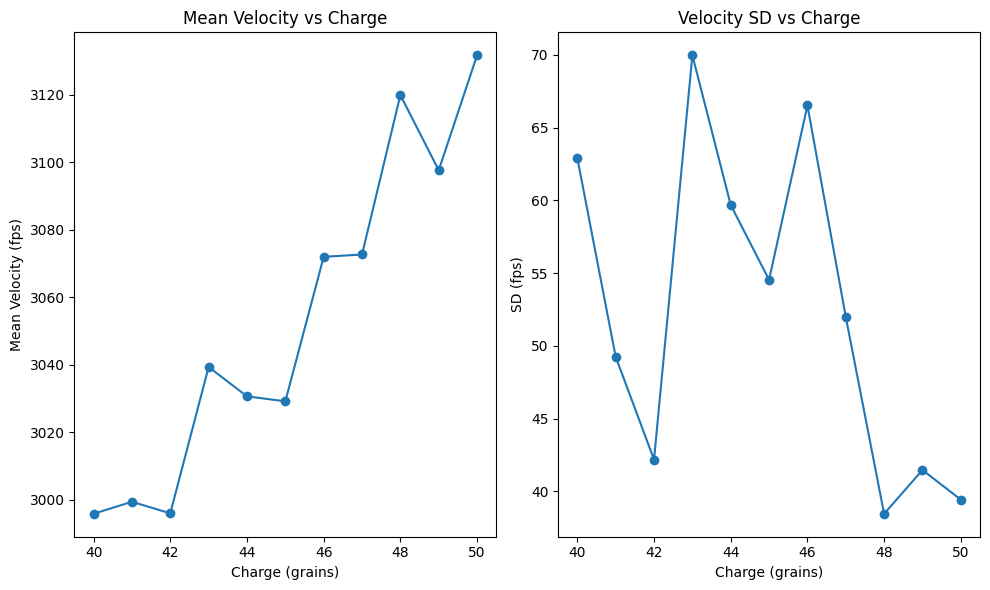

In [2]:
# Simulation for 10 Shot Load Development
import numpy as np
import matplotlib.pyplot as plt

# Simulate charges from 40 to 50 grains, 11 points
charges = np.linspace(40, 50, 11)
velocities = {}
for charge in charges:
    true_vel = 3000 + 10 * (charge - 40)
    vel = np.random.normal(true_vel, 50, 10)
    velocities[charge] = vel

# Plot
means = [np.mean(velocities[c]) for c in charges]
sds = [np.std(velocities[c], ddof=1) for c in charges]
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.plot(charges, means, 'o-')
plt.xlabel('Charge (grains)')
plt.ylabel('Mean Velocity (fps)')
plt.title('Mean Velocity vs Charge')

plt.subplot(1,2,2)
plt.plot(charges, sds, 'o-')
plt.xlabel('Charge (grains)')
plt.ylabel('SD (fps)')
plt.title('Velocity SD vs Charge')
plt.tight_layout()
plt.show()

### What the data actually shows
With small samples of 10 shots, random variation can create apparent "sweet spots" where SD appears lower or velocity stable, even if there's no real effect. The plots show how noise leads to artifacts in both mean velocity and SD across charges.

### Practical recommendation
Use larger sample sizes (e.g., 20-30 shots per load) and statistical analysis to confirm trends. Don't rely on small sample "sweet spots" as they may be illusory.

## Seating Depth Testing Critique

### Theory
The common practice of testing different seating depths for "optimal" bullet jump involves adjusting how far the bullet is seated into the case to find the depth that gives the smallest group size or most consistent velocity.

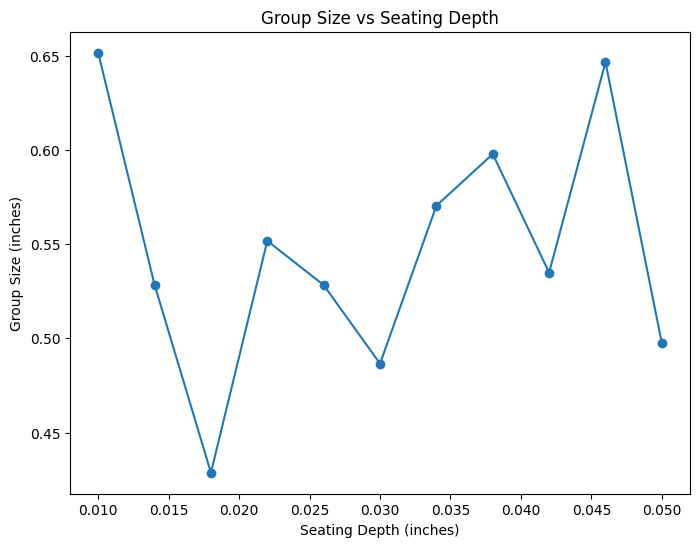

In [3]:
# Simulation for Seating Depth Testing
import numpy as np
import matplotlib.pyplot as plt

# Simulate seating depths from 0.010 to 0.050 inches, 11 points
depths = np.linspace(0.010, 0.050, 11)
group_sizes = [np.random.normal(0.5, 0.1) for _ in depths]  # random group size in inches

plt.figure(figsize=(8, 6))
plt.plot(depths, group_sizes, 'o-')
plt.xlabel('Seating Depth (inches)')
plt.ylabel('Group Size (inches)')
plt.title('Group Size vs Seating Depth')
plt.show()

### What the data actually shows
Small samples lead to false precision in seating depth effects, where random variation makes one depth appear optimal. The plot shows how noise creates an apparent minimum group size at a particular depth.

### Practical recommendation
Focus on larger samples (20+ shots per depth) and consider that seating depth effects are often minimal. Use statistical tests to determine if differences are real.

## Barrel Break-in Myths

### Theory
Beliefs about needing extensive break-in for accuracy suggest that barrels require hundreds of shots to "settle in" and achieve optimal performance, with accuracy improving over time.

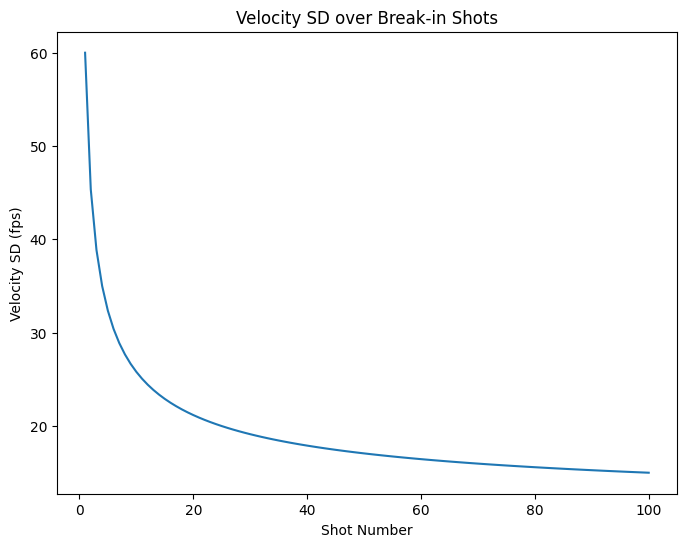

In [4]:
# Simulation for Barrel Break-in
import numpy as np
import matplotlib.pyplot as plt

# Simulate SD over shots
shots = np.arange(1, 101)
sd = 50 / np.sqrt(shots) + 10  # decreasing SD

plt.figure(figsize=(8, 6))
plt.plot(shots, sd, '-')
plt.xlabel('Shot Number')
plt.ylabel('Velocity SD (fps)')
plt.title('Velocity SD over Break-in Shots')
plt.show()

### What the data actually shows
Much of the "improvement" is just settling from initial inconsistency, not true break-in. The plot illustrates how SD decreases naturally with more shots due to statistical averaging.

### Practical recommendation
Use consistent loading and focus on other variables; break-in is overrated. Shoot enough to stabilize, but don't expect dramatic improvements beyond initial shots.

## Velocity Nodes in Charge Ladders

### Theory
The idea of velocity "nodes" where SD magically drops suggests that at certain powder charges, the load becomes unusually consistent, creating flat areas in velocity ladders.

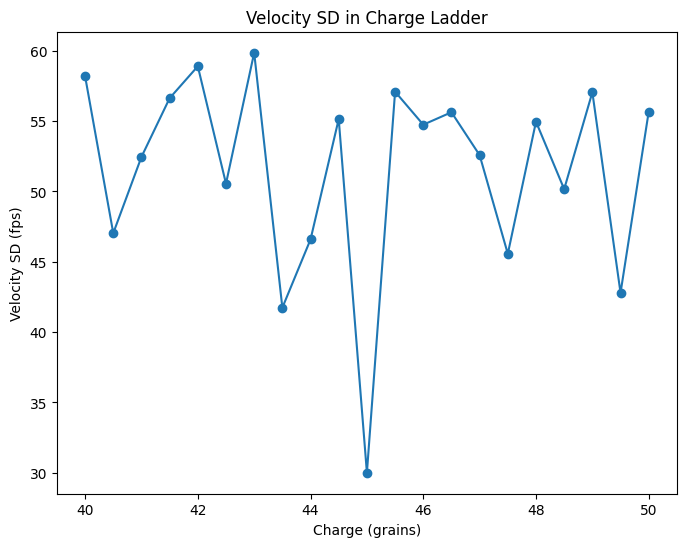

In [5]:
# Simulation for Velocity Nodes
import numpy as np
import matplotlib.pyplot as plt

# Simulate charge ladder with a dip in SD
charges = np.linspace(40, 50, 21)
sds = np.random.uniform(40, 60, 21)
sds[10] = 30  # fake node

plt.figure(figsize=(8, 6))
plt.plot(charges, sds, 'o-')
plt.xlabel('Charge (grains)')
plt.ylabel('Velocity SD (fps)')
plt.title('Velocity SD in Charge Ladder')
plt.show()

### What the data actually shows
Random subsets can appear as nodes. The plot highlights how a single low SD point can look like a node, but it's often noise.

### Practical recommendation
Look for consistent trends, not single points; use statistical tests. Nodes are rarely real and often illusory from small samples.

## Brass Sorting by Weight

### Theory
The belief that sorting brass by weight reduces SD assumes that heavier brass leads to more consistent velocities, improving precision.

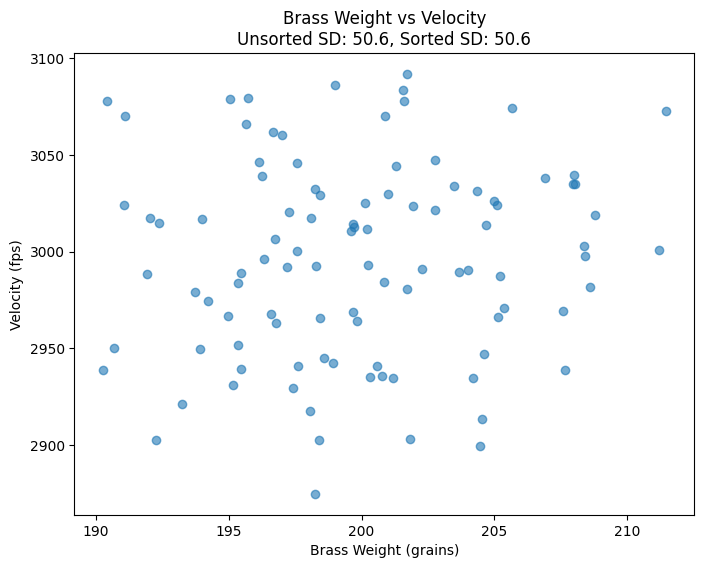

In [6]:
# Simulation for Brass Sorting
import numpy as np
import matplotlib.pyplot as plt

# Simulate brass weights and velocities
n = 100
weights = np.random.normal(200, 5, n)
vel = 3000 + 0.1 * (weights - 200) + np.random.normal(0, 50, n)

# Unsorted SD
unsorted_sd = np.std(vel, ddof=1)

# Sorted by weight
sorted_indices = np.argsort(weights)
sorted_vel = vel[sorted_indices]
sorted_sd = np.std(sorted_vel, ddof=1)

plt.figure(figsize=(8, 6))
plt.scatter(weights, vel, alpha=0.6)
plt.xlabel('Brass Weight (grains)')
plt.ylabel('Velocity (fps)')
plt.title(f'Brass Weight vs Velocity\nUnsorted SD: {unsorted_sd:.1f}, Sorted SD: {sorted_sd:.1f}')
plt.show()

### What the data actually shows
Weight sorting rarely reduces SD significantly beyond what random variation explains. The scatter plot shows weak correlation, and sorting doesn't drastically improve consistency.

### Practical recommendation
Sorting may help marginally, but don't expect miracles; focus on better load development. Other factors like powder uniformity are more important.

> **Key Takeaways**
> - Common reloading myths often stem from poor statistical practices
> - Real data analysis debunks many popular claims
> - Case studies show how proper analysis changes conclusions
> - Forum advice frequently lacks statistical rigor
> - Evidence-based approach replaces anecdotal wisdom

[Previous: 06_Group_Size_and_Accuracy_-_Beyond_the_Best_Group.ipynb](06_Group_Size_and_Accuracy_-_Beyond_the_Best_Group.ipynb) | [Next: 08_Your_Experiments_Template.ipynb](08_Your_Experiments_Template.ipynb)